### Previous work with models

In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_dt = pd.read_csv('../models_performances_22032025.csv')
evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)

In [4]:
evaluations_dt2 = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_22042025/*.csv')
evaluations_dt = evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1')) ] 

/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantIn

In [5]:
evaluations_dt2[evaluations_dt2['HLA'] == 'A1101']

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path
48,A1101,Hubber,HLA,0.8,30,0.0001,0.0001,110,0.732367,0.734125,1.166454,0.788916,0.385084,1.080025,2025-04-23 01:46:26,/global/scratch/users/sergiomar10/losses/ESMCB...
92,A1101,Hubber,epitope,0.95,30,0.0001,0.0001,110,0.787887,0.781715,0.750055,0.683913,0.604596,0.866057,2025-04-23 03:01:35,/global/scratch/users/sergiomar10/losses/ESMCB...
125,A1101,Hubber,HLA,0.85,30,0.0001,0.0001,110,0.789466,0.763282,0.817398,0.709153,0.569095,0.904100,2025-04-23 02:10:33,/global/scratch/users/sergiomar10/losses/ESMCB...
247,A1101,Hubber,epitope,0.85,30,0.0001,0.0001,110,0.706796,0.703373,1.116295,0.825610,0.411526,1.056549,2025-04-23 02:56:53,/global/scratch/users/sergiomar10/losses/ESMCB...
260,A1101,Hubber,epitope,0.8,30,0.0001,0.0001,110,0.774275,0.752930,0.832946,0.718779,0.560898,0.912659,2025-04-23 03:04:54,/global/scratch/users/sergiomar10/losses/ESMCB...
344,A1101,Hubber,HLA,0.95,30,0.0001,0.0001,110,0.791990,0.759437,0.845442,0.713024,0.554311,0.919479,2025-04-23 00:10:27,/global/scratch/users/sergiomar10/losses/ESMCB...


In [6]:
evaluations_dt = pd.concat([evaluations_dt, evaluations_dt2], axis=0)
evaluations_dt = evaluations_dt.reset_index(drop=True)

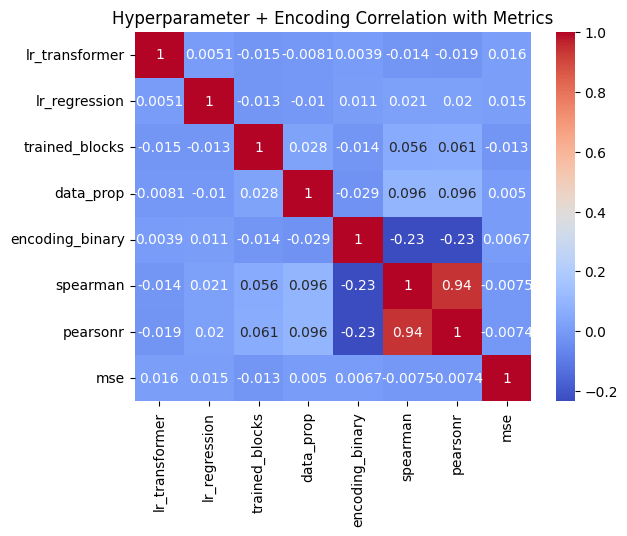

Encoding vs Spearman correlation: nan (p = nan)


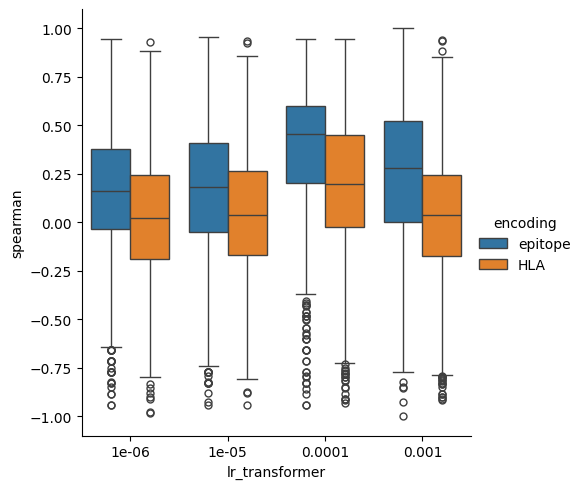

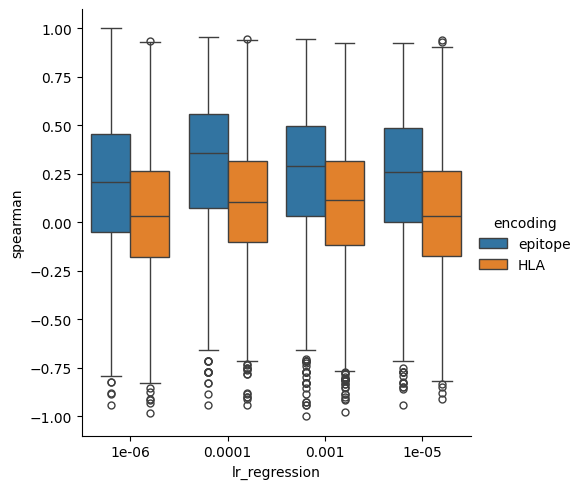

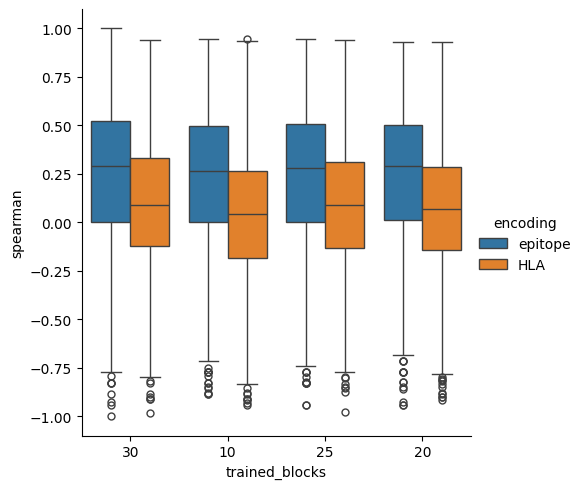

In [7]:
# Copy the DataFrame
df_corr = evaluations_dt.copy()

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['Losses_binary'] = df_corr['Losses'].map({'MSE': 0, 'Hubber': 1})

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['encoding_binary'] = df_corr['encoding'].map({'epitope': 0, 'HLA': 1})

# Select numeric columns
numeric_hyperparams = df_corr[[
    'lr_transformer', 'lr_regression', 'trained_blocks', 'data_prop', 'encoding_binary',  'spearman', 'pearsonr', 'mse'
]].astype(float)

# Compute correlation matrix
correlation_matrix = numeric_hyperparams.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Hyperparameter + Encoding Correlation with Metrics")
plt.show()


from scipy.stats import pointbiserialr
# Point-biserial correlation
r, p = pointbiserialr(df_corr['encoding_binary'], df_corr['spearman'])
print(f"Encoding vs Spearman correlation: {r:.3f} (p = {p:.3g})")

evaluations_dt['lr_transformer'] = evaluations_dt['lr_transformer'].astype(float)

# sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='encoding', kind='box')

In [8]:
evaluations_dt[(evaluations_dt['HLA'] == ('A1101'))]['encoding'].unique()

array(['HLA', 'epitope'], dtype=object)

In [9]:
evaluations_dt_sorted =  evaluations_dt.sort_values(by='mse', ascending = True)
evaluations_dt_sorted['Model'] = evaluations_dt_sorted['HLA'] + ' ' + evaluations_dt_sorted['encoding']
evaluations_dt_sorted = evaluations_dt_sorted.drop_duplicates('Model')
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [10]:
evaluations_dt_sorted[(evaluations_dt_sorted['HLA'] == ('A1101'))]

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model
187,A1101,Hubber,HLA,0.5,30,0.0001,0.0001,110,0.797718,0.783970,0.736651,0.654020,0.611662,0.858284,2025-04-18 06:36:05,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
12869,A1101,Hubber,epitope,0.95,30,0.0001,0.0001,110,0.787887,0.781715,0.750055,0.683913,0.604596,0.866057,2025-04-23 03:01:35,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 epitope


In [11]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

All test datasets were empty for HLA B3501 epitope. Skipping this allele.


In [12]:
# pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time','Model']], on='Model', how='left').reset_index(drop=True).sort_values(by=['HLA_x','Model'], ascending=True).head(30)

In [13]:
hla_sequences = []

# Process each HLA and its evaluation file
for hla, eval_path in evaluations_dt_sorted[['HLA', 'path']].values:

    # # Load evaluation data
    dt = pd.read_csv(eval_path)
    sequences = dt['sequence'].unique()
    hla_formatted = f"HLA-{hla}"  # e.g., 'HLA-A1101'

    # Collect HLA and sequence pairs
    for seq in sequences:
        hla_sequences.append([hla_formatted, seq])


In [14]:
# # Load Data S2: Monoallelic benchmark dataset with predictions
# test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [15]:
# test_data['hla'] = test_data['hla'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [16]:
# evaluations_dt_sorted = evaluations_dt[evaluations_dt['encoding'] == 'epitope'].sort_values(by='mse', ascending = True) #.drop_duplicates('HLA') #[evaluations_dt['Losses'] == 'MSE']
# evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# # evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [17]:
# IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/IEDB_full_subset_filtered_out_MHCFlurry.csv', sep = ',', header = 0)
# IEDB_full.head()

In [18]:
# IEDB_full['HLA'] = IEDB_full['MHC Restriction - Name'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

### RFDiffusion

In [19]:
# import pandas as pd

# evaluations_dt_sorted = pd.read_csv('../../performances/models_performances_23042025.csv')
# # evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'A0201']
# rfd_peptides = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/rdfiffusion_output_peptides.csv')
# # rfd_peptides = rfd_peptides[(rfd_peptides['length'] < 12) & (rfd_peptides['hla_allele'] == 'HLA-A*0201')]
# print(len(rfd_peptides))
# rfd_peptides.head(2)

# rfd_peptides['HLA'] = [x.replace('HLA-','').replace('*','') for x in rfd_peptides['hla_allele'].astype('str')] 
# rfd_peptides['title'].str.replace('HLA-','').str.extract(r'([A-Z]\d{2}\d{2})')[0].unique()


In [20]:
# hlas_in_rfd = rfd_peptides['hla_allele'].unique()
# hlas_in_rfd

In [21]:
# rfd_peptides.drop_duplicates().groupby('hla_allele').size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(20)

In [22]:
# peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')
# peptides_eval_set_ESMCBA = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == 'A0201 epitope']
# peptides_eval_set_ESMCBA.head()

In [23]:
import random

AA = list("ACDEFGHIKLMNPQRSTVWY")
N_MUTANTS = 10

# Anchor positions (0-indexed) for nonamers and decamers
ANCHORS = {
    9: (1, 8),   # P2 and PΩ for 9-mers
   10: (1, 9)    # P2 and PΩ for 10-mers
}

def mutate_non_anchors(seq, rng):
    L = len(seq)
    anchors = ANCHORS.get(L)
    if not anchors:
        # sequence length not supported → return original
        return seq
    s = list(seq)
    for i in range(L):
        if i in anchors:
            continue
        s[i] = rng.choice(AA)
    return "".join(s)

def generate_mutants(seqs, seed=0):
    rng = random.Random(seed)
    mutants = []
    for seq in seqs:
        L = len(seq)
        if L not in ANCHORS:
            # skip sequences of unsupported lengths
            continue
        for _ in range(N_MUTANTS):
            mutants.append(mutate_non_anchors(seq, rng))
    return mutants

In [24]:
# from transformers import AutoTokenizer, EsmForMaskedLM
# import torch
# import numpy as np

# # Check if GPU is available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # Load the tokenizer and model
# tok = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
# model = EsmForMaskedLM.from_pretrained("facebook/esm2_t33_650M_UR50D").to(device).eval()

# # Define standard amino acids (exclude special and ambiguous tokens)
# standard_amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
# amino_acid_ids = [tok.convert_tokens_to_ids(aa) for aa in standard_amino_acids]

# def generate_9mers_with_esm2(n_samples=10, temperature=1.0):
#     samples = []
#     with torch.no_grad():
#         for _ in range(n_samples):
#             # Initialize sequence: [CLS] <mask> <mask> ... <mask> (9 masks)
#             seq = [tok.cls_token_id] + [tok.mask_token_id] * 9
#             seq_tensor = torch.tensor([seq]).to(device)  # Ensure tensor is on the same device as model

#             # Iteratively predict each masked position
#             for pos in range(1, 10):  # Positions 1 to 9
#                 # Get logits for the current sequence
#                 outputs = model(seq_tensor).logits  # Shape: [1, seq_len, vocab_size]
#                 logits = outputs[0, pos, :] / temperature  # Logits for the masked position

#                 # Restrict to standard amino acids
#                 logits = logits[amino_acid_ids]
#                 probs = torch.softmax(logits, dim=-1)
#                 next_id = amino_acid_ids[torch.multinomial(probs, 1).item()]

#                 # Update the sequence with the predicted token
#                 seq_tensor[0, pos] = next_id

#             # Decode the sequence (skip [CLS])
#             seq_str = tok.decode(seq_tensor[0, 1:], skip_special_tokens=True)
#             samples.append(seq_str)

#     return samples

In [25]:
# # Example usage
# samples = generate_9mers_with_esm2(n_samples=500, temperature=1.0)
# for i, sample in enumerate(samples):
#     print(f"Sample {i+1}: {sample}")

In [26]:
# # import pandas as pd

# # #join all sequences 'P P N P K K D D E' to 'PPNPKKDD'and make them in a dataframe
# # samples_df = pd.DataFrame(samples, columns=['sequence'])
# # samples_df['sequence'] = samples_df['sequence'].str.replace(' ', '')
# # samples_df.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/9mers_esm2.csv', index=False)

# samples_df = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/9mers_esm2.csv')

In [27]:
# import matplotlib.pyplot as plt
# import logomaker
# import os

# # Define standard amino acids
# amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# # Output directory for saving figures
# output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
# os.makedirs(output_dir, exist_ok=True)

# # Loop through epitope lengths
# for n in range(8, 15):
#     # Filter sequences from ESCMBA_predictions
#     sequences = [x for x in mutant_df if len(x) == n] #.tolist()
#         # print(sequences)
#     # Only proceed if sequences are found
#     if sequences:
#         # Initialize frequency matrix
#         freq_matrix = np.zeros((n, len(amino_acids)))

#         # Compute frequency for each position and amino acid
#         for seq in sequences:
#             if len(seq) == n:  # Ensure sequence length matches
#                 for j, aa in enumerate(seq):
#                     if aa in amino_acids:
#                         freq_matrix[j, amino_acids.index(aa)] += 1
#         # break
#         # Normalize by number of sequences
#         if len(sequences) > 0:
#             freq_matrix /= len([seq for seq in sequences if len(seq) == n])

#         # Create DataFrame for logomaker
#         freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

#         # Create figure and axis
#         fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

#         # Generate sequence logo
#         logomaker.Logo(freq_df, ax=ax, color_scheme='chemistry')
#         ax.set_xlabel("Position")
#         ax.set_ylabel("Frequency")
#         ax.set_xticks(range(n))
#         ax.set_xticklabels(range(1, n + 1))
#         ax.set_title(f"Sequence Logo for {n}-mer Epitopes")

#         # Save figure
#         output_path = os.path.join(output_dir, f'seqlogo_{n}_random_peptides_mer.pdf')
#         plt.savefig(output_path, bbox_inches='tight')
#         plt.show()
#     else:
#         print(f"No sequences found for length {n}")

#     # Close figure to free memory
#     plt.close(fig)

In [28]:

    # # Save to .pep FASTA file
    # pepe = allele_clean.replace('HLA', 'HLA-')
    # fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    # with open(fasta_filename, "w") as fout:
    #     for i, pep in enumerate(cleaned_peptides, 1):
    #         fout.write(f">pep{i}\n{pep}\n")

    # print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # # Build mhcflurry and netMHCpan commands
    # mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    # mhcflurry_cmd = (
    #     f"mhcflurry-predict --alleles {allele_clean} "
    #     f"--peptides {' '.join(cleaned_peptides)} "
    #     f"--out {mhcflurry_outfile}"
    # )

    # netmhc_cmd = (
    #     f"cd {output_dir} && "
    #     f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
    #     f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    # )

In [29]:
# eval_model_df = pd.DataFrame(evaluated_models_log)

In [30]:
# eval_model_df['model_path'] = eval_model_df['model_path'].str.replace('/global/scratch/users/sergiomar10/models/','')

In [31]:
# import shutil

# destination_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA'
# os.makedirs(destination_dir, exist_ok=True)

# for row in evaluated_models_log:
#     src = row['model_path']
#     filename = os.path.basename(src)
#     dest = os.path.join(destination_dir, filename)

#     try:
#         shutil.copy2(src, dest)  # copy2 preserves metadata
#         print(f"✅ Copied {filename} to {destination_dir}")
#     except Exception as e:
#         print(f"❌ Failed to copy {src} → {dest}: {e}")


### Generation of SH Files

In [15]:
import sys, os
os.path.dirname(sys.executable)
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [16]:
# Load Data S3: Training data for MHCflurry 2.0 BA predictor
training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S3.csv')
print(f"Training data shape: {training_data.shape}")
training_data['allele'] = training_data['allele'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix
training_data['allele'] = training_data['allele'].str.replace('HLA','')

Training data shape: (713069, 12)


In [3]:
pd.set_option('display.max.columns',None)

In [35]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)
IEDB_full.head()

/tmp/ipykernel_1051541/1962146925.py:1: DtypeWarning: Columns (6,12,13,14,19,20,21,22,23,24,25,26,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,60,61,62,63,64,65,66,67,68,70,71,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)


,Assay ID - IEDB IRI,Reference - IEDB IRI,Reference - Type,Reference - PMID,Reference - Submission ID,Reference - Authors,Reference - Journal,Reference - Date,Reference - Title,Epitope - Epitope IRI,Epitope - Object Type,Epitope - Name,Epitope - Reference Name,Epitope - Modified residues,Epitope - Modifications,Epitope - Starting Position,Epitope - Ending Position,Epitope - IRI,Epitope - Synonyms,Epitope - Source Molecule,Epitope - Source Molecule IRI,Epitope - Molecule Parent,Epitope - Molecule Parent IRI,Epitope - Source Organism,Epitope - Source Organism IRI,Epitope - Species,Epitope - Species IRI,Epitope - Comments,Related Object - Epitope Relation,Related Object - Object Type,Related Object - Name,Related Object - Starting Position,Related Object - Ending Position,Related Object - IRI,Related Object - Synonyms,Related Object - Source Molecule,Related Object - Source Molecule IRI,Related Object - Molecule Parent,Related Object - Molecule Parent IRI,Related Object - Source Organism,Related Object - Source Organism IRI,Related Object - Species,Related Object - Species IRI,Host - Name,Host - IRI,Host - Geolocation,Host - Geolocation IRI,Host - Sex,Host - Age,Host - MHC Types Present,in vivo Process - Process Type,in vivo Process - Disease,in vivo Process - Disease IRI,in vivo Process - Disease Stage,in vivo Antigen - Epitope Relation,in vivo Antigen - Object Type,in vivo Antigen - Name,in vivo Antigen - Reference Name,in vivo Antigen - Starting Position,in vivo Antigen - Ending Position,in vivo Antigen - IRI,in vivo Antigen - Source Molecule,in vivo Antigen - Source Molecule IRI,in vivo Antigen - Molecule Parent,in vivo Antigen - Molecule Parent IRI,in vivo Antigen - Source Organism,in vivo Antigen - Source Organism IRI,in vivo Antigen - Species,in vivo Antigen - Species IRI,in vivo Antigen - Adjuvants,in vivo Antigen - Route,in vivo Antigen - Dose Schedule,In vitro Process - Process Type,In vitro Process - Epitope Relation,In vitro Process - Object Type,In vitro Process - Name,In vitro Process - Reference Name,In vitro Process - Starting Position,In vitro Process - Ending Position,In vitro Process - IRI,In vitro Process - Source Molecule,In vitro Process - Source Molecule IRI,In vitro Process - Molecule Parent,In vitro Process - Molecule Parent IRI,In vitro Process - Source Organism,In vitro Process - Source Organism IRI,In vitro Process - Species,In vitro Process - Species IRI,Antigen Processing - Comments,Assay - Location of Assay Data in Reference,Assay - Method,Assay - Response measured,Assay - Units,Assay - IRI,Assay - Qualitative Measurement,Assay - Measurement Inequality,Assay - Quantitative measurement,Assay - Number of Subjects Tested,Assay - Number of Subjects Responded,Assay - Response Frequency (%),Assay - PDB ID,Assay - Comments,Antigen Presenting Cell - Source Tissue,Antigen Presenting Cell - Source Tissue IRI,Antigen Presenting Cell - Name,Antigen Presenting Cell - IRI,Antigen Presenting Cell - Culture Condition,MHC Restriction - Name,MHC Restriction - IRI,MHC Restriction - Evidence Code,MHC Restriction - Evidence IRI,MHC Restriction - Class
0,http://www.iedb.org/assay/26,http://www.iedb.org/reference/274,Literature,15448372.0,NaN,Yi-Hsiang Huang; Mi-Hua Tao; Cheng-Po Hu; Wan-...,J Gen Virol,2004,Identification of novel HLA-A*0201-restricted ...,http://www.iedb.org/epitope/31803,Linear peptide,KLEDLERDL,HDV 26-34,NaN,NaN,26.0,34.0,NaN,NaN,large delta antigen,http://www.ncbi.nlm.nih.gov/protein/AAG26087.1,Large delta antigen,http://www.uniprot.org/uniprot/P29996,Hepatitis delta virus TW2667,https://ontology.iedb.org/ontology/ONTIE_0000432,Hepatitis delta virus,http://purl.obolibrary.org/obo/NCBITaxon_12475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fig

In [36]:
# training_data[training_data['allele'] == 'HLAA0201']['peptide'].unique()

In [37]:
IEDB_full['allele'] = IEDB_full['MHC Restriction - Name'].str.replace('*','').str.replace('HLA-','').str.replace(':','')

In [38]:
evaluations_dt_sorted = pd.read_csv('../../data/evaluations_dt_sorted_29062025_w_dup.csv')

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

In [39]:
evaluations_dt_sorted

,Unnamed: 0,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum
0,5433,A3101,Hubber,HLA,0.95,30,NaN,4.0000,8,0.976190,0.960705,0.288154,0.460769,0.806094,0.536800,2025-05-28 18:10:32,/global/scratch/users/sergiomar10/losses/ESMCB...,A3101 HLA,2.0,1.0,3.0
1,5371,B0802,Hubber,epitope,0.60,30,0.0001,0.0001,8,0.951503,0.962579,0.169187,0.389041,0.747436,0.411324,2025-05-28 21:51:23,/global/scratch/users/sergiomar10/losses/ESMCB...,B0802 epitope,4.0,1.0,5.0
2,35,B4801,Hubber,epitope,0.60,30,0.0001,0.0001,19,0.943313,0.949175,0.330350,0.513690,0.790287,0.574761,2025-05-28 22:32:54,/global/scratch/users/sergiomar10/losses/ESMCB...,B4801 epitope,4.0,1.0,5.0
3,3250,B1402,Hubber,epitope,0.95,30,NaN,5.0000,6,0.942857,0.694225,0.971401,0.965530,-13.916207,0.985597,2025-05-28 13:01:26,/global/scratch/users/sergiomar10/losses/ESMCB...,B1402 epitope,12.0,1.5,13.5
4,760,B8301,Hubber,epitope,0.20,30,0.0001,0.0001,6,0.941124,0.887281,0.225505,0.321255,0.553748,0.474874,2025-05-28 10:01:22,/global/scratch/users/sergiomar10/losses/ESMCB...,B8301 epitope,7.0,1.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,3750,B2720,Hubber,epitope,0.40,0,0.0001,0.0001,2,0.000000,0.000000,0.004479,0.047917,0.394175,0.066922,2025-05-28 22:40:44,/global/scratch/users/sergiomar10/losses/ESMCB...,B2720 epitope,1.0,21.5,22.5
148,5175,B2720,Hubber,HLA,0.80,30,NaN,5.0000,3,0.000000,0.000000,0.011500,0.101004,-0.153712,0.107237,2025-05-28 17:22:47,/global/scratch/users/sergiomar10/losses/ESMCB...,B2720 HLA,1.0,22.5,23.5
149,3148,A6601,Hubber,HLA,0.80,30,0.0001,0.0001,3,0.000000,0.000000,0.008913,0.094381,0.000000,0.094411,2025-05-28 21:27:16,/global/scratch/users/sergiomar10/losses/ESMCB...,A6601 HLA,1.0,22.5,23.5
150,2922,B4013,Hubber,HLA,0.60,30,NaN,4.0000,3,0.000000,0.000000,0.000378,0.012088,-1.605758,0.019437,2025-05-28 19:51:37,/global/scratch/users/sergiomar10/losses/ESMCB...,B4013 HLA,1.0,22.5,23.5


In [40]:
import pandas as pd

epitope_dict = {}

for allele in alleles:
    allele_clean = allele.split(' ')[0]
    file_path = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{allele_clean}_final.csv"

    try:
        # Load SQL-based epitope data
        epitope_data = pd.read_csv(file_path, header=None)
        epitope_data.columns = [
            'sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin',
            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission'
        ]
        epitope_sequences = set(epitope_data['sequence'].unique())
        epitope_dict[allele_clean] = list(epitope_sequences)

        # Get training peptides for this allele
        training_peptides = set(training_data[training_data['allele'] == allele_clean]['peptide'].unique())

        # Get all IEDB peptides for this allele
        full_iedb_peptides = IEDB_full[IEDB_full['allele'] == allele_clean]['Epitope - Name'].unique()
        full_iedb_peptides_set = set(full_iedb_peptides)

        # Peptides not used in training or SQL epitope set
        not_in_models = full_iedb_peptides_set - training_peptides - epitope_sequences

        # Cross-check overlaps (should be empty ideally)
        overlap_train = training_peptides & not_in_models
        overlap_sql = epitope_sequences & not_in_models

        # Print summary
        print(f"\n=== {allele_clean} ===")
        print(f"Total IEDB entries: {len(full_iedb_peptides_set)}")
        print(f"Not used in models: {len(not_in_models)}")
        print(f"Overlap with training data: {len(overlap_train)}")
        print(f"Overlap with SQL epitope data: {len(overlap_sql)}")

        # Optional: show the actual overlaps
        if overlap_train:
            print(f"⚠️  Found {len(overlap_train)} peptides in training unexpectedly:")
            print(overlap_train)

        if overlap_sql:
            print(f"⚠️  Found {len(overlap_sql)} peptides in SQL file unexpectedly:")
            print(overlap_sql)

    except FileNotFoundError:
        print(f"⚠️  File not found for {allele_clean}")
    except Exception as e:
        print(f"❌ Error processing {allele_clean}: {e}")



=== A3101 ===
Total IEDB entries: 8075
Not used in models: 760
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B0802 ===
Total IEDB entries: 431
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B4801 ===
Total IEDB entries: 877
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B1402 ===
Total IEDB entries: 2833
Not used in models: 1219
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B8301 ===
Total IEDB entries: 333
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B0802 ===
Total IEDB entries: 431
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== A2501 ===
Total IEDB entries: 3936
Not used in models: 1072
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== A2501 ===
Total IEDB entries: 3936
Not used in models: 1072
Overlap with training data: 0
Overlap with SQL epitope d


=== B4601 ===
Total IEDB entries: 4629
Not used in models: 346
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== A2603 ===
Total IEDB entries: 270
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== A1101 ===
Total IEDB entries: 17649
Not used in models: 5648
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B5301 ===
Total IEDB entries: 4145
Not used in models: 919
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B8301 ===
Total IEDB entries: 333
Not used in models: 0
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== C0702 ===
Total IEDB entries: 3171
Not used in models: 1037
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B1801 ===
Total IEDB entries: 9002
Not used in models: 3423
Overlap with training data: 0
Overlap with SQL epitope data: 0

=== B4601 ===
Total IEDB entries: 4629
Not used in models: 346
Overlap with training data: 0
Overlap with SQL ep

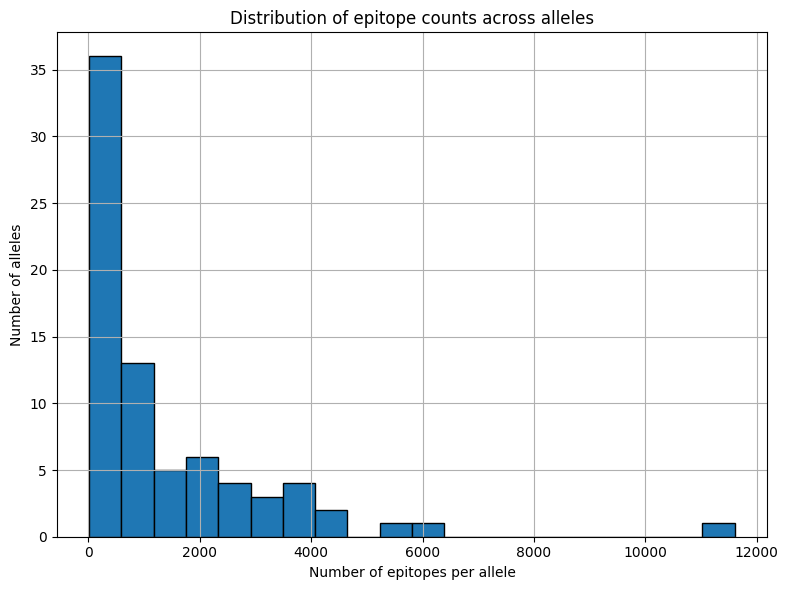

In [41]:
import matplotlib.pyplot as plt

# Get counts of epitopes per allele
epitope_lengths = [len(seqs) for seqs in epitope_dict.values()]
allele_labels = list(epitope_dict.keys())

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(epitope_lengths, bins=20, edgecolor='black')
plt.xlabel("Number of epitopes per allele")
plt.ylabel("Number of alleles")
plt.title("Distribution of epitope counts across alleles")
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
# evaluations_dt_sorted[evaluations_dt_sorted['path'].str.contains('False')] # [ 'Model'].unique()

In [43]:
evaluations_dt_sorted[evaluations_dt_sorted['Model'].str.contains('A0201')]['path'].values #.sort_values(by='spearman', ascending=False)['path'].values

array(['/global/scratch/users/sergiomar10/losses/ESMCBA_28062025/evaluation_ESMCBA_HLA_0.8_30_False-Full_pretraining_100000_seq_AUG_3_ALL_HLAS_0.0001_0.0001__5_A0201_0404_Hubber_A0201.csv',
       '/global/scratch/users/sergiomar10/losses/ESMCBA_28062025/evaluation_ESMCBA_epitope_0.2_30_ESMMASK_epitope_FT_15_0.001_1e-05_AUG_3_A0201_2_0.0001_0.0001__7_A0201_0404_Hubber_A0201.csv'],
      dtype=object)

In [4]:
evaluation = pd.read_csv('../evaluations_full_02062025.csv')

In [6]:
# ensure rows are sorted by descending Spearman, then grab the top-3 per (Model, pretrain)
top3 = (
    evaluation
      .sort_values('spearman', ascending=False)          # highest first
      .groupby(['Model', 'pretrain'], as_index=False)    # group on both keys
      .head(3)                                           # take first three rows of each group
      [['spearman', 'path', 'Model', 'pretrain']]        # keep requested columns
      .reset_index(drop=True)                            # tidy index
)

# quick look
top3[top3['Model'].str.contains('A0201')].sort_values(by='spearman', ascending=False)


,spearman,path,Model,pretrain
528,0.570516,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Pretrained
529,0.570203,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 HLA,Not Pretrained
533,0.568016,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Pretrained
536,0.566516,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Pretrained
543,0.557199,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 HLA,Not Pretrained
546,0.555151,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Not Pretrained
569,0.538588,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Not Pretrained
574,0.533163,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 epitope,Not Pretrained
580,0.525444,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 HLA,Pretrained
587,0.522101,/global/scratch/users/sergiomar10/losses/ESMCB...,A0201 HLA,Pretrained


In [12]:
def compute_model_path(row):
    model_fn = os.path.basename(row.path).replace('evaluation_', '').replace('.csv', '_final.pth')
    allele_clean = row.Model.split()[0].replace('*', '').replace(':', '')
    return f'/global/scratch/users/sergiomar10/models/ESMCBA_21032025/{allele_clean}/{model_fn}'

top3['model_path_clean'] = top3.apply(compute_model_path, axis=1)


In [14]:
top3 = top3[top3['model_path_clean'].apply(os.path.exists)].reset_index(drop=True)


In [ ]:
model_path = row.model_path_clean


In [11]:
model_fn

'ESMCBA_HLA_0.6_30_ESMMASK_HLA_FT_15_0.001_1e-05_AUG_1_B1502_1_0.0001_0.0001__7_B1502_0404_Hubber_B1502_final.pth'

In [23]:
import os, re, numpy as np, pandas as pd

# --- directories ---
name               = 'benchmark_on_unseen_epitopes_'
sh_file_dir        = '/global/scratch/users/sergiomar10/slurm_jobs/benchmark_02062025'
output_dir         = '/global/scratch/users/sergiomar10/data/benchmark_02062025'
mhcflurry_out_dir  = output_dir
logs_dir           = '/global/scratch/users/sergiomar10/slurm_jobs/benchmark/logs'

for d in (sh_file_dir, output_dir, mhcflurry_out_dir, logs_dir):
    os.makedirs(d, exist_ok=True)

# -------- MAIN LOOP --------
for row in top3.itertuples(index=False):
    model_path = row.model_path_clean
    model_string  = row.Model.strip()                 # e.g. "A0201 epitope"
    pretrain_bool = row.pretrain

    # Extract allele and tag
    allele_code   = model_string.split()[0]           # e.g. 'A0201'
    allele_clean  = allele_code.replace('*', '').replace(':', '')
    allele        = f"{allele_clean}"

    # Tags
    input_tag     = model_string.split()[1]           # 'epitope' or 'HLA'
    pretrain_tag  = 'Pretrained' if pretrain_bool else 'NonPretrained'
    model_tag     = f"{allele_clean}_{input_tag}_{pretrain_tag}"

    # Get short model name from path, remove .pt or .pth
    tail = os.path.basename(model_path)

    tail = re.sub(r'\.pt[h]?$', '', tail)

    # Build unique run ID
    run_id = f"{model_tag}_{tail}"

    # Load peptides from IEDB CSV
    file_path = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{allele_clean}_final.csv"
    try:
        epitope_data = pd.read_csv(file_path, header=None)
        epitope_data.columns = [
            'sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin',
            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission'
        ]
        epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)

        epitope_data = epitope_data[epitope_data['Year_submission'] > 2019]

        epitope_sequences = set(epitope_data['sequence'].dropna().unique())

    except FileNotFoundError:
        print(f"❌ No IEDB CSV for {allele_clean}: {file_path}")
        continue

    # Clean and filter peptides
    peptides = [p for p in epitope_sequences
                if isinstance(p, str) and 8 <= len(p) <= 11 and not re.search(r'[<>()*\s+]', p)]

    if len(peptides) == 0:
        print(f"⚠️ No valid peptides found for {allele_clean}")
        continue

    print(f"🔬 {allele_clean}: using all {len(peptides)} peptides from IEDB CSV")

    # Generate peptide string for CLI tools
    pep_str = ' '.join(peptides)

    # Write FASTA for NetMHCpan
    # fasta_file = os.path.join(output_dir, f"{name}{allele_clean}.pep")
    # with open(fasta_file, 'w') as fh:
    #     for i, pep in enumerate(peptides, 1):
    #         fh.write(f">pep{i}\n{pep}\n")

    # --- COMMANDS ---

    output_name = model_path.split('/')[-1].replace('.pth', '').replace('.pt', '')

    # ESMCBA embedding command
    esmcba_cmd = (
        "conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian\n"
        f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/embeddings_generation.py "
        f"--model_path {model_path} "
        f"--name {allele}-{output_name} "
        f"--hla {allele} "
        f"--encoding {input_tag} "
        f"--output_dir {output_dir} "
        f"--peptides {pep_str}"
    )

    # MHCflurry prediction command (optional)
    mhcflurry_cmd = (
        "conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n"
        "mhcflurry-predict "
        f"--alleles {allele_clean} "
        f"--peptides {pep_str} "
        f"--out {os.path.join(mhcflurry_out_dir, f'{allele_clean}__mhcflurry.csv')}"
    )

    # NetMHCpan command (optional)
    netmhc_cmd = (
        f"cd {output_dir} && "
        "/global/scratch/users/sergiomar10/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele} -f {fasta_file} -BA -xls -xlsfile netmhc_{allele_clean}.xls"
    )

    # --- WRITE SLURM SCRIPT ---
    for tag, cmd in (('esmcba', esmcba_cmd),
                    #  ('mhcflurry', mhcflurry_cmd),
                    #  ('netmhcpan', netmhc_cmd)
                    ):
        tag_run_id = f"{run_id}_{tag}"
        sh_path    = os.path.join(sh_file_dir, f"{name}{tag_run_id}.sh")

        with open(sh_path, 'w') as sb:
            sb.write("#!/bin/bash\n")
            sb.write('#SBATCH --account=co_nilah\n')
            sb.write('#SBATCH --partition=savio3_gpu\n')
            sb.write('#SBATCH --qos=savio_lowprio\n')
            sb.write('#SBATCH --cpus-per-task=4\n')
            sb.write('#SBATCH --gres=gpu:1\n')
            sb.write('#SBATCH --requeue\n')
            sb.write("#SBATCH --time=00:40:00\n")
            sb.write(f"#SBATCH --job-name={tag_run_id}\n")
            sb.write(f"#SBATCH --output={logs_dir}/{tag_run_id}_%j.out\n")
            sb.write(f"#SBATCH --error={logs_dir}/{tag_run_id}_%j.err\n\n")
            sb.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
            sb.write(cmd + "\n")

        os.chmod(sh_path, 0o755)
        print(f"✅ Wrote {tag} script: {sh_path}")


🔬 A3101: using all 8 peptides from IEDB CSV
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark_02062025/benchmark_on_unseen_epitopes_A3101_HLA_Pretrained_ESMCBA_HLA_0.95_30_False-Full_pretraining_100000_seq_AUG_3_ALL_HLAS_0.0001_0.0001__4_A3101_0404_Hubber_A3101_final_esmcba.sh
⚠️ No valid peptides found for B0802
⚠️ No valid peptides found for B4801
⚠️ No valid peptides found for B8301
⚠️ No valid peptides found for B0802
⚠️ No valid peptides found for B0802
⚠️ No valid peptides found for B0802
⚠️ No valid peptides found for A2403
⚠️ No valid peptides found for C1203
⚠️ No valid peptides found for A0202
⚠️ No valid peptides found for A0202
⚠️ No valid peptides found for A2403
⚠️ No valid peptides found for A0202
⚠️ No valid peptides found for A2403
🔬 B1801: using all 12 peptides from IEDB CSV
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark_02062025/benchmark_on_unseen_epitopes_B1801_HLA_Pretrained_ESMCBA_HLA_0.4_30_ESMMASK_HLA_F

In [ ]:
import os
import re
import numpy as np
import pandas as pd

name = 'benchmark_on_unseen_epitopes_'
sh_file_dir       = '/global/scratch/users/sergiomar10/slurm_jobs/benchmark'
output_dir        = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/benchmark'
mhcflurry_out_dir = output_dir
logs_dir          = '/global/scratch/users/sergiomar10/slurm_jobs/benchmark/logscd'

for d in (sh_file_dir, output_dir, mhcflurry_out_dir, logs_dir):
    os.makedirs(d, exist_ok=True)

for allele in evaluations_dt_sorted['HLA'].unique():
    allele_clean = allele.replace("*", "").replace(":", "")

    # Skip if allele not in epitope_dict
    if allele_clean not in epitope_dict or len(epitope_dict[allele_clean]) == 0:
        print(f"⚠️ Skipping {allele_clean}: no peptides")
        continue

    # Sample up to 1000 unseen peptides
    peptides = epitope_dict[allele_clean]
    peptides = [pep for pep in peptides if 8 <= len(pep) <= 11 and not re.search(r'[<\(\)\*\s\+]', pep)]
    if len(peptides) == 0:
        print(f"⚠️ No valid peptides for {allele_clean}")
        continue

    sampled_peptides = np.random.choice(peptides, size=min(1000, len(peptides)), replace=False)
    print(f"🔬 {allele_clean}: using {len(sampled_peptides)} peptides")

    # Write FASTA file
    fasta_file = os.path.join(output_dir, f"benchmark_on_unseen_epitopes_{allele_clean}.pep")
    with open(fasta_file, 'w') as f:
        for i, pep in enumerate(sampled_peptides, 1):
            f.write(f">pep{i}\n{pep}\n")

    for model_name in evaluations_dt_sorted['Model'].unique():
        for _, eval_path in evaluations_dt_sorted[
            (evaluations_dt_sorted['HLA'] == allele) &
            (evaluations_dt_sorted['Model'] == model_name)
        ][['HLA', 'path']].values:

            allele_fmt = allele_clean.replace('HLA', '')
            if allele_fmt not in model_name:
                continue

            model_fn = os.path.basename(eval_path).replace('evaluation_', '').replace('.csv', '_final.pth')
            model_path = f"/global/scratch/users/sergiomar10/models/ESMCBA_21032025/{allele_fmt}/{model_fn}"

            if not os.path.exists(model_path):
                print(f"❌ Model not found: {model_path}")
                continue

            encoding = model_name.split(' ')[1]
            model_name_clean = model_name.replace(' ', '_')
            run_id = f"{model_name_clean}_benchmark_{allele_clean}"
            pep_str = ' '.join(sampled_peptides)
            pepe = allele_clean.replace('HLA', 'HLA-')

            # COMMANDS:
            esmcba_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian\n"
                f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/embeddings_generation.py "
                f"--model_path {model_path} --name {model_name_clean}-{allele} "
                f"--hla {allele} --encoding {encoding} --output_dir {output_dir} "
                f"--peptides {pep_str}"
            )

            mhcflurry_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n"
                f"mhcflurry-predict "
                f"--alleles {allele_clean} "
                f"--peptides {pep_str} "
                f"--out {os.path.join(mhcflurry_out_dir, f'{allele_clean}__mhcflurry.csv')}"
            )

            netmhc_cmd = (
                f"cd {output_dir} && "
                f"/global/scratch/users/sergiomar10/tools/netMHCpan-4.1/netMHCpan "
                f"-a HLA-{allele_clean} -f {fasta_file} -BA -xls -xlsfile netmhc_{allele_clean}.xls"
            )

            # PACK & WRITE SCRIPTS
            for tag, cmd in (('esmcba', esmcba_cmd), ('mhcflurry', mhcflurry_cmd), ('netmhcpan', netmhc_cmd)):
                tag_run_id = f"{run_id}_{tag}"
                sh_path = os.path.join(sh_file_dir, f"{name}{tag_run_id}.sh")

                with open(sh_path, 'w') as sb:
                    sb.write("#!/bin/bash\n")
                    sb.write('#SBATCH --account=co_nilah\n')
                    sb.write('#SBATCH --partition=savio3_gpu\n')
                    sb.write('#SBATCH --qos=savio_lowprio\n')
                    sb.write('#SBATCH --cpus-per-task=4\n')
                    sb.write('#SBATCH --gres=gpu:1\n')
                    sb.write('#SBATCH --requeue\n')
                    sb.write("#SBATCH --time=00:40:00\n")
                    sb.write(f"#SBATCH --job-name={tag_run_id}\n")
                    sb.write(f"#SBATCH --output={logs_dir}/{tag_run_id}_%j.out\n")
                    sb.write(f"#SBATCH --error={logs_dir}/{tag_run_id}_%j.err\n\n")
                    sb.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
                    sb.write(cmd + "\n")

                os.chmod(sh_path, 0o755)
                print(f"✅ Wrote {tag} script: {sh_path}")

            break  # Only process the first matching model per allele


🔬 A3101: using 1000 peptides
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_HLA_benchmark_A3101_esmcba.sh
✅ Wrote mhcflurry script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_HLA_benchmark_A3101_mhcflurry.sh
✅ Wrote netmhcpan script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_HLA_benchmark_A3101_netmhcpan.sh
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_epitope_benchmark_A3101_esmcba.sh
✅ Wrote mhcflurry script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_epitope_benchmark_A3101_mhcflurry.sh
✅ Wrote netmhcpan script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_A3101_epitope_benchmark_A3101_netmhcpan.sh
🔬 B0802: using 431 peptides
✅ Wrote esmcba script: /global/scratch/users/serg

✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_HLA_benchmark_B5801_esmcba.sh
✅ Wrote mhcflurry script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_HLA_benchmark_B5801_mhcflurry.sh
✅ Wrote netmhcpan script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_HLA_benchmark_B5801_netmhcpan.sh
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_epitope_benchmark_B5801_esmcba.sh
✅ Wrote mhcflurry script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_epitope_benchmark_B5801_mhcflurry.sh
✅ Wrote netmhcpan script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/benchmark_on_unseen_epitopes_B5801_epitope_benchmark_B5801_netmhcpan.sh
🔬 A0205: using 106 peptides
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/benchmark/

KeyboardInterrupt: 

🔬 A3101: using 1000 peptides


KeyboardInterrupt: 

In [ ]:
eval_path.replace('/','_')

'_global_scratch_users_sergiomar10_losses_ESMCBA_22042025_evaluation_ESMCBA_HLA_0.95_30_ESMMASK_HLA_FT_15_0.001_1e-06_AUG_3_B4601_1_0.0001_0.0001__1_B4601_0404_Hubber_B4601.csv'

In [ ]:
model_name

'B1501 epitope'

In [19]:
evaluations_dt_sorted

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model
5916,B1542,Hubber,HLA,0.95,20,0.0001,0.00001,14,0.172005,0.026365,0.000331,0.017606,-20.299145,0.018193,2025-04-18 11:42:00,/global/scratch/users/sergiomar10/losses/ESMCB...,B1542 HLA
12715,B2703,Hubber,HLA,0.8,25,0.0010,0.0001,10,NaN,NaN,0.000712,0.026654,0.000000,0.026688,2025-04-18 11:14:27,/global/scratch/users/sergiomar10/losses/ESMCB...,B2703 HLA
13042,B2701,Hubber,HLA,0.8,30,0.0001,0.0001,2,0.000000,0.000000,0.003216,0.056535,0.000000,0.056713,2025-04-23 02:45:12,/global/scratch/users/sergiomar10/losses/ESMCB...,B2701 HLA
12908,B2703,Hubber,epitope,0.8,30,0.0001,0.0001,10,NaN,NaN,0.009952,0.076781,0.000000,0.099759,2025-04-23 03:03:10,/global/scratch/users/sergiomar10/losses/ESMCB...,B2703 epitope
13120,B2702,Hubber,epitope,0.8,30,0.0001,0.0001,2,0.000000,0.000000,0.012423,0.098523,-10.091120,0.111460,2025-04-23 02:56:22,/global/scratch/users/sergiomar10/losses/ESMCB...,B2702 epitope
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3065,A2402,Hubber,epitope,0.8,30,0.0010,0.000001,132,0.386791,0.363239,2.391129,1.189590,0.095922,1.546328,2025-04-18 14:29:59,/global/scratch/users/sergiomar10/losses/ESMCB...,A2402 epitope
12975,A0101,Hubber,HLA,0.8,30,0.0001,0.0001,128,0.596230,0.625658,2.435254,1.268939,0.078633,1.560530,2025-04-22 23:56:12,/global/scratch/users/sergiomar10/losses/ESMCB...,A0101 HLA
12955,A2402,Hubber,HLA,0.85,30,0.0001,0.0001,132,0.324210,0.266909,2.554623,1.219391,0.034106,1.598319,2025-04-23 02:51:58,/global/scratch/users/sergiomar10/losses/ESMCB...,A2402 HLA
12814,B4402,Hubber,epitope,0.85,30,0.0001,0.0001,118,0.426380,0.401515,2.834341,1.414398,-0.642998,1.683550,2025-04-23 02:55:21,/global/scratch/users/sergiomar10/losses/ESMCB...,B4402 epitope


In [ ]:
import os
import re
import numpy as np 

name = 'FINAL_RS_RFD_MAC_'
# Set up directories
sh_file_dir       = '/global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH'
output_dir        = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'
mhcflurry_out_dir = os.path.join(output_dir, 'mhcflurry')
logs_dir          = '/global/scratch/users/sergiomar10/logs/RFD_BENCHMARK'

for d in (sh_file_dir, output_dir, mhcflurry_out_dir, logs_dir):
    os.makedirs(d, exist_ok=True)

peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')

for allele in evaluations_dt_sorted['HLA'].unique():

    # peptides_eval_set_ESMCBA_subset = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['HLA'] == allele]
    # rfd_peptides_subset = rfd_peptides[rfd_peptides['HLA'] == allele]

    # #add the RFD peptides to the evaluation set
    # peptides = pd.concat([peptides_eval_set_ESMCBA_subset['sequence'], rfd_peptides_subset['epitope']])
    
    # #add the mutated peptides
    # mutant_df = generate_mutants(peptides_eval_set_ESMCBA_subset["sequence"])

    # mutant_dt = pd.DataFrame(mutant_df, columns=['sequence'])
    # mutant_dt['HLA'] = allele
    # mutant_dt = mutant_dt.head(500)
    # #save mutant_df
    # mutant_dt.to_csv(f'/global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/mutant_peptides/mutant_df_{allele}.csv', index=False)

    # peptides = np.concatenate([peptides, mutant_df[:500]])


    # #add randomly sampled ESM2 peptides
    # peptides = np.concatenate([peptides, samples_df['sequence'].values])

    print(f'{allele} - {len(peptides)} peptides')

    for hla in evaluations_dt_sorted['Model'].unique():
        rows = evaluations_dt_sorted[
            evaluations_dt_sorted['HLA'] == allele
        ][['HLA','path']].values

        for allele, eval_path in rows:
            # clean names
            allele_clean = allele.split()[0].replace('*','').replace(':','').replace(' ','')
            hla_clean    = allele_clean.replace('HLA','')

            if hla_clean not in hla:
                print(f"⚠️ HLA mismatch: {hla_clean} not in {hla}")
                continue

            model_fn     = os.path.basename(eval_path).replace('evaluation_','').replace('.csv','_final.pth')
            model_path   = f'/global/scratch/users/sergiomar10/models/ESMCBA_21032025/{hla_clean}/{model_fn}'

            if not os.path.exists(model_path):
                print(f"❌ Model missing: {model_path}")
                continue
            print(f"✅ Using model: {model_path}")

            cleaned = [
                pep for pep in peptides
                if 8 <= len(pep) <= 11 and not re.search(r'[<\(\)\*\s\+]', pep)
            ]
            if not cleaned:
                print(f"⚠️ No peptides for {allele}")
                continue

            # write .pep FASTA
            pepe       = allele_clean.replace('HLA','HLA-')
            fasta_file = os.path.join(output_dir, f"{pepe}.pep")
            with open(fasta_file,'w') as f:
                for i, pep in enumerate(cleaned,1):
                    f.write(f">pep{i}\n{pep}\n")

            hla = hla.replace(' ','_')
            encoding = hla.split('_')[1]

            # build commands
            esmcba_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian \n"
                f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/embeddings_generation.py "
                f"--model_path {model_path} "
                f"--name {hla}-{allele} "
                f"--hla {allele} "
                f"--encoding {encoding} "
                f"--output_dir {output_dir} "
                f"--peptides {' '.join(cleaned)}"
            )
            mhcflurry_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools \n"
                f"mhcflurry-predict --alleles {allele_clean} "
                f"--peptides {' '.join(cleaned)} "
                f"--out {os.path.join(output_dir, allele_clean+name+'_mhc_flurry.csv')}"
            )
            netmhc_cmd = (
                f"cd {output_dir} && "
                f"/global/scratch/users/sergiomar10/tools/netMHCpan-4.1/netMHCpan "
                f"-a HLA-{allele_clean} -f {pepe}.pep -BA -xls -xlsfile {name}_{allele_clean}_netmhc.xls"
            )
            

            # package them up
            for tag, cmd in (('esmcba', esmcba_cmd),
                            ('mhcflurry', mhcflurry_cmd),
                            ('netmhcpan', netmhc_cmd)):

                if tag == 'esmcba':
                    run_id = f"{hla}_{tag}"
                    sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
                else:
                    run_id = f"{hla}_{tag}"
                    sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
                with open(sh_path,'w') as sb:
                    sb.write("#!/bin/bash\n")
                    sb.write("#SBATCH --account=co_nilah\n")
                    sb.write("#SBATCH --partition=savio3_gpu\n")
                    sb.write("#SBATCH --cpus-per-task=4\n")
                    sb.write('#SBATCH --qos=savio_lowprio\n')
                    sb.write("#SBATCH --gres=gpu:1\n")
                    sb.write("#SBATCH --time=00:40:00\n")
                    sb.write(f"#SBATCH --job-name={run_id}\n")
                    sb.write(f"#SBATCH --output={logs_dir}/{run_id}_%j.out\n")
                    sb.write(f"#SBATCH --error={logs_dir}/{run_id}_%j.err\n\n")
                    sb.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
                    # sb.write("")
                    sb.write(cmd + "\n")

                os.chmod(sh_path, 0o755)
                print(f"✅ Wrote {tag} script: {sh_path}")

            break

In [17]:
testing_set_filtered = pd.DataFrame()

for HLA in test_datasets_df['HLA'].unique():
    training_data_subset = training_data[training_data['allele'] == HLA]

    test_datasets_df_subset = test_datasets_df[test_datasets_df['HLA'] == HLA]
    test_datasets_df_subset = test_datasets_df_subset[~test_datasets_df_subset['sequence'].isin(training_data_subset['peptide'])]

    testing_set_filtered = pd.concat([testing_set_filtered, test_datasets_df_subset], ignore_index=True)

In [18]:
testing_set_filtered

,sequence,prediction,measured,HLA
0,NaN,2.679751,2.686636,C0802 epitope
1,NaN,2.700665,2.913284,C0802 epitope
2,NaN,2.693427,2.867467,C0802 epitope
3,NaN,2.689547,2.567026,C0802 epitope
4,NaN,2.661148,2.761176,C0802 epitope
...,...,...,...,...
3299,EEFLDPSRPY,3.059291,1.623249,B4402 epitope
3300,EENSTGSLY,2.013229,2.824776,B4402 epitope
3301,EEQCLQWDL,2.612629,2.290035,B4402 epitope
3302,FAFRDLCIVY,2.644078,1.716003,B3501 epitope


In [ ]:
import os
import pandas as pd

# Load your test data
# testing_set_filtered = pd.read_csv("path/to/testing_set_filtered.csv")

# Output dirs
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA'
output_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4'
mhcflurry_out_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry'
os.makedirs(sh_file_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mhcflurry_out_dir, exist_ok=True)

aa = set("ACDEFGHIKLMNPQRSTVWY")  # valid amino acids

# Loop through each HLA in testing set
unique_hlas = testing_set_filtered['HLA'].unique()
print(f"📊 Found {len(unique_hlas)} unique HLAs in testing set.")

for allele in unique_hlas:
    allele_peptides = testing_set_filtered[testing_set_filtered['HLA'] == allele]['sequence'].unique()
    allele_clean = allele.replace('HLA-', '').replace('*', '').replace(':', '').replace(' ', '')

    # Clean peptides
    cleaned_peptides = [
        ''.join([aa_ for aa_ in p if aa_.upper() in aa])
        for p in allele_peptides if isinstance(p, str)
    ]
    cleaned_peptides = [p for p in cleaned_peptides if p]

    if len(cleaned_peptides) == 0:
        print(f"⚠️ No valid peptides found for {allele}. Skipping.")
        continue

    run_id = f"EVAL_MHCFLURRY_TEST_{allele_clean}"

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

    # Write SLURM script
    sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    try:
        with open(sh_filepath, 'w') as sh_file:
            sh_file.write('#!/bin/bash\n')
            sh_file.write('#SBATCH --account=co_nilah\n')
            sh_file.write('#SBATCH --partition=savio2_1080ti\n')
            sh_file.write('#SBATCH --qos=savio_lowprio\n')
            sh_file.write('#SBATCH --cpus-per-task=4\n')
            sh_file.write('#SBATCH --gres=gpu:1\n')
            sh_file.write('#SBATCH --time=00:40:00\n')
            sh_file.write(f'#SBATCH --job-name={run_id}\n')
            sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
            sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n\n')
            sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
            sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n\n')
            sh_file.write(f"{mhcflurry_cmd}\n")
            sh_file.write(f"{netmhc_cmd}\n")

        os.chmod(sh_filepath, 0o755)
        print(f"✅ Created SLURM script: {sh_filepath}")
    except Exception as e:
        print(f"❌ Error writing script for {allele}: {e}")


NameError: name 'testing_set_filtered' is not defined

In [ ]:
allele_clean.replace('HLA', 'HLA-')

'HLA-A2402'